# How end-to-end training works

End-to-end training unfreezes the DNA encoder and trains it jointly with the head.
Two pieces make it fit in memory (e2e does **not** use the variant cache yet):

1. **Window aggregation** — a batch of samples is reduced to the *unique* windows
   it references; the encoder embeds those once into a table `E`, and each sample's
   prediction is pooled from its windows' rows of `E` (sum / mean via an index map),
   then passed to the head.
2. **Gradient caching** (manual activation checkpointing) — a batch touches tens of
   thousands of windows, far too many to hold the encoder's autograd graph for. So
   we embed once **without** a graph and cache `dL/dE`, then **recompute** the
   encoder in chunks to accumulate its parameter gradients.

Implementation: [train_pipeline/train_end2end.py](../train_pipeline/train_end2end.py).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from pathlib import Path
%matplotlib inline

FIGS = Path("/home/andrew.dickson/svar/presentation/figs"); FIGS.mkdir(parents=True, exist_ok=True)

C_SHARED = "#e7edf3"; C_VAR = "#e8833a"; C_EDGE = "#9aa7b4"
C_ENC = "#eaf0f6"; C_HEAD = "#fdeee2"; C_CACHE = "#e7f3ea"
GREEN = "#2e7d4f"; RED = "#c0392b"; INK = "#33414f"

def cell(ax, x, y, w=1.0, h=1.0, color=C_SHARED, lw=0.7, ec=C_EDGE):
    ax.add_patch(Rectangle((x, y), w, h, facecolor=color, edgecolor=ec, lw=lw))

def box(ax, x, y, w, h, text, fc="#f4f6f8", ec="#5b6b7b", fs=10, lw=1.4, tc="black"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                 facecolor=fc, edgecolor=ec, lw=lw))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs, color=tc)

def arrow(ax, a, b, color=INK, lw=2.0, style="-|>"):
    ax.annotate("", xy=b, xytext=a, arrowprops=dict(arrowstyle=style, color=color,
                                                    lw=lw, shrinkA=2, shrinkB=2))

def vec(ax, x, y, rows, w=0.5, h=0.16, gap=0.04, color="#cfe0f0"):
    for r in range(rows):
        cell(ax, x, y + r*(h+gap), w, h, color=color)
print("helpers ready")


## 1. Window aggregation (the forward pass)

The batch's `(sample, window)` references are deduplicated to the unique windows,
embedded once by the encoder into `E (n_unique × D)`, then each sample's vector is
**pooled** from the rows of `E` for its windows (`embedding_bag`, sum or mean, via
the `inverse` index). The head maps those per-sample vectors to trait predictions.


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5.4))

# --- batch of samples (rows of window cells; grey = reference, orange = variant) ---
rng = np.random.default_rng(2)
B, W = 4, 8
for i in range(B):
    y = 3.6 - i*0.62
    for j in range(W):
        cell(ax, 0.3 + j*0.34, y, 0.30, 0.42,
             color=(C_VAR if rng.random() < 0.18 else C_SHARED))
    ax.text(0.2, y + 0.21, f"s{i+1}", ha="right", va="center", fontsize=9)
ax.text(0.3 + W*0.34/2, 4.05, "batch: B samples × windows", ha="center", fontsize=10)

arrow(ax, (3.15, 2.6), (3.9, 2.6))
ax.text(3.5, 3.0, "gather_batch\ndedup windows", ha="center", fontsize=8.5, color=INK)

box(ax, 3.95, 2.0, 1.7, 1.25, "Encoder\n(DNA LM)", fc=C_ENC, fs=10)
arrow(ax, (5.7, 2.6), (6.3, 2.6))

# E table (n_unique rows x D)
vec(ax, 6.4, 1.55, 7, w=1.5, h=0.18, gap=0.05, color="#cfe0f0")
ax.text(7.15, 1.4, "E : (n_unique × D)", ha="center", va="top", fontsize=9)

# pooling -> per-sample vectors
arrow(ax, (8.0, 2.6), (9.1, 2.6))
ax.text(8.55, 3.2, "pool each sample's\nwindows\n(embedding_bag,\ninverse index)",
        ha="center", fontsize=8.3, color=GREEN)
vec(ax, 9.2, 1.85, B, w=1.4, h=0.3, gap=0.08, color="#bfe0c9")
ax.text(9.9, 1.7, "per-sample (B × D)", ha="center", va="top", fontsize=9)

arrow(ax, (10.65, 2.6), (11.2, 2.6))
box(ax, 11.25, 2.05, 1.5, 1.15, "Head", fc=C_HEAD, ec="#cf7a3a", fs=10)
arrow(ax, (12.8, 2.6), (13.3, 2.6))
box(ax, 13.35, 2.0, 1.5, 1.25, "predictions\n(B × traits)\n→ loss", fc="#f4f6f8", fs=9)

ax.set_xlim(0, 15.1); ax.set_ylim(0.7, 4.5); ax.axis("off")
ax.set_title("Window aggregation: dedup → embed once → pool per sample → head", fontsize=13)
fig.tight_layout(); fig.savefig(FIGS / "11_e2e_window_aggregation.png", dpi=150,
                                bbox_inches="tight"); plt.show()


## 2. Gradient caching (two-pass backward)

A batch references far too many windows to hold the encoder's autograd graph for
all of them. **Pass 1** embeds them with no graph and backprops only through the
head, caching `E.grad = dL/dE` (tiny: `n_unique × D`). **Pass 2** recomputes the
encoder one chunk at a time and backprops the cached gradient slice to accumulate
encoder parameter grads. Peak memory = `E` + a single chunk's encoder graph.


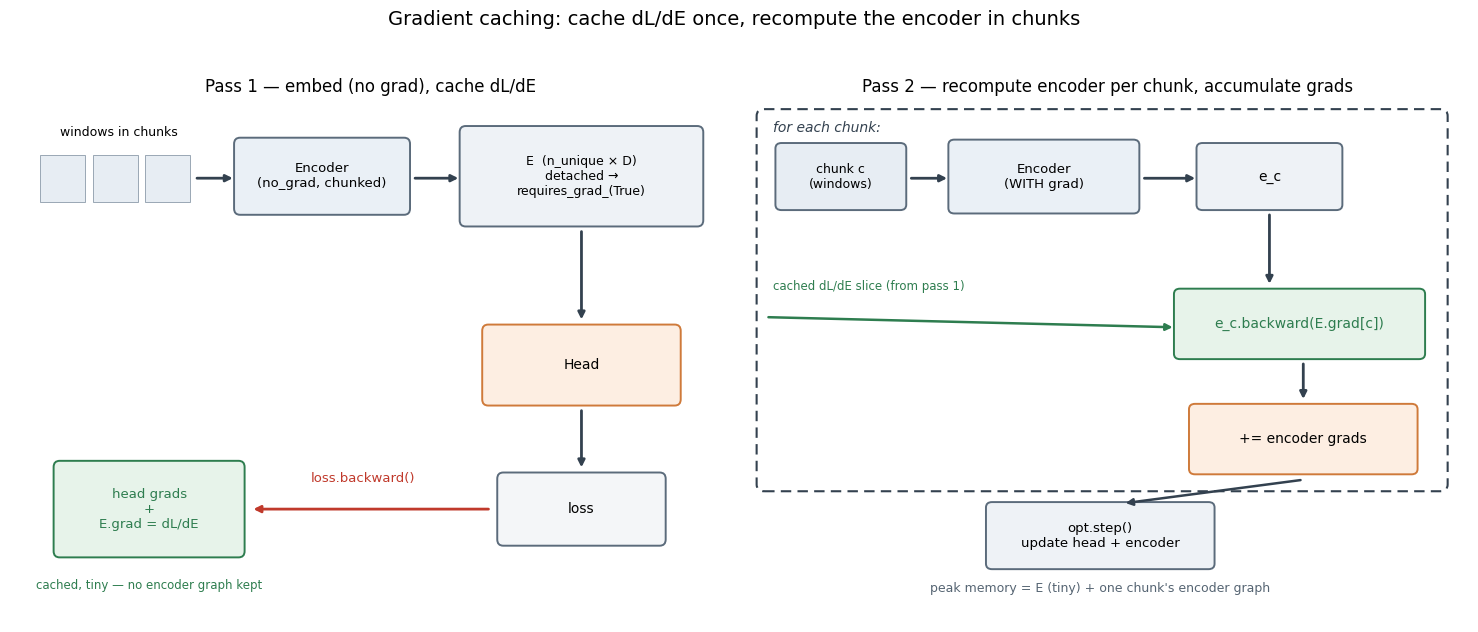

In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6.4))

# ---------- Pass 1: no encoder graph, cache dL/dE ----------
axL.set_title("Pass 1 — embed (no grad), cache dL/dE", fontsize=12)
for k in range(3):
    cell(axL, 0.4 + k*0.7, 8.1, 0.6, 0.6, color=C_SHARED)
axL.text(1.45, 8.95, "windows in chunks", ha="center", fontsize=9)
box(axL, 3.0, 7.95, 2.3, 0.95, "Encoder\n(no_grad, chunked)", fc=C_ENC, fs=9.5)
arrow(axL, (2.45, 8.4), (3.0, 8.4))
box(axL, 6.0, 7.8, 3.2, 1.25, "E  (n_unique × D)\ndetached →\nrequires_grad_(True)",
    fc="#eef2f6", fs=9)
arrow(axL, (5.35, 8.4), (6.0, 8.4))
box(axL, 6.3, 5.5, 2.6, 1.0, "Head", fc=C_HEAD, ec="#cf7a3a", fs=10)
arrow(axL, (7.6, 7.75), (7.6, 6.55))
box(axL, 6.5, 3.7, 2.2, 0.9, "loss", fc="#f4f6f8", fs=10)
arrow(axL, (7.6, 5.45), (7.6, 4.65))
# backward (cache grads)
arrow(axL, (6.4, 4.15), (3.2, 4.15), color=RED, lw=2.0)
axL.text(4.7, 4.5, "loss.backward()", ha="center", fontsize=9.5, color=RED)
box(axL, 0.6, 3.55, 2.5, 1.2, "head grads\n+\nE.grad = dL/dE", fc=C_CACHE, ec=GREEN,
    fs=9.5, tc=GREEN)
axL.text(1.85, 3.25, "cached, tiny — no encoder graph kept", ha="center", va="top",
         fontsize=8.5, color=GREEN)
axL.set_xlim(0, 9.6); axL.set_ylim(2.7, 9.4); axL.axis("off")

# ---------- Pass 2: recompute encoder per chunk, accumulate grads ----------
axR.set_title("Pass 2 — recompute encoder per chunk, accumulate grads", fontsize=12)
box(axR, 0.4, 7.6, 1.7, 0.95, "chunk c\n(windows)", fc=C_SHARED, fs=9)
box(axR, 2.7, 7.55, 2.5, 1.05, "Encoder\n(WITH grad)", fc=C_ENC, fs=9.5)
arrow(axR, (2.15, 8.05), (2.7, 8.05))
box(axR, 6.0, 7.6, 1.9, 0.95, "e_c", fc="#eef2f6", fs=10)
arrow(axR, (5.25, 8.05), (6.0, 8.05))
# cached gradient slice feeds the chunk backward
box(axR, 5.7, 5.4, 3.3, 1.0, "e_c.backward(E.grad[c])", fc=C_CACHE, ec=GREEN, fs=10, tc=GREEN)
arrow(axR, (6.95, 7.55), (6.95, 6.45))
# the cached dL/dE comes from pass 1 (enters the loop from outside, left edge)
arrow(axR, (0.25, 6.0), (5.7, 5.85), color=GREEN, lw=1.8)
axR.text(0.35, 6.4, "cached dL/dE slice (from pass 1)", ha="left", fontsize=8.5, color=GREEN)
box(axR, 5.9, 3.7, 3.0, 1.0, "+= encoder grads", fc="#fdeee2", ec="#cf7a3a", fs=10)
arrow(axR, (7.4, 5.35), (7.4, 4.75))
# dashed container: everything above repeats once per chunk (replaces the
# orphaned loop arrow — the whole block IS the per-chunk body).
axR.add_patch(FancyBboxPatch((0.15, 3.45), 9.15, 5.6,
              boxstyle="round,pad=0.02,rounding_size=0.10",
              facecolor="none", edgecolor=INK, lw=1.5, ls=(0, (5, 3))))
axR.text(0.35, 8.8, "for each chunk:", ha="left", va="center", fontsize=10,
         color=INK, style="italic")
box(axR, 3.2, 2.3, 3.0, 0.95, "opt.step()\nupdate head + encoder", fc="#eef2f6", fs=9.5)
arrow(axR, (7.4, 3.6), (5.0, 3.25), color=INK, lw=1.8)   # exit loop -> step
axR.text(4.7, 1.95, "peak memory = E (tiny) + one chunk's encoder graph",
         ha="center", fontsize=9, color="#566573")
axR.set_xlim(0, 9.6); axR.set_ylim(1.5, 9.2); axR.axis("off")

fig.suptitle("Gradient caching: cache dL/dE once, recompute the encoder in chunks",
             fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGS / "12_e2e_gradient_caching.png", dpi=150, bbox_inches="tight"); plt.show()


**Why two passes are equivalent to one.** The chain rule factors as
`dL/dθ = (dL/dE) · (dE/dθ)`. Pass 1 computes the first factor exactly (the head's
backward gives `E.grad`); pass 2 supplies the second by recomputing each chunk's
encoder forward and seeding its backward with the cached `E.grad` slice. With the
encoder in `eval()` the two forwards are bit-identical, so the accumulated encoder
grads match a single full-graph backward — verified by
`train_end2end.py --sanity-check`. The cost is one extra encoder forward (the
recompute); the saving is never holding more than one chunk's graph at a time.
